# Hyperliquid × Bitcoin Fear/Greed Index
### Trader Behavior & Performance Analysis - How Market Sentiment Drives Trader Behavior on Hyperliquid

# Visualization — Presentation-Ready Outputs

**Goal:** Produce clean, publication-quality charts that tell the story
without needing the analysis notebooks open.

**Principles:**
- One key message per chart — title states the conclusion, not just the metric
- Before/after comparisons where possible
- Consistent color encoding (Red = Fear, Green = Greed, Gray = Neutral)
- Every chart is self-contained (axis labels, source annotation)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

df = pd.read_csv('clean_trades.csv', parse_dates=['date'])
close_df = df[df['is_close']].copy()
sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
palette = {'Extreme Fear': '#C04828', 'Fear': '#E8593C',
           'Neutral': '#888780', 'Greed': '#1D9E75', 'Extreme Greed': '#0F6E56'}
colors = [palette[s] for s in sent_order]

### Chart 1 — Dashboard Summary: 3 Core Metrics at a Glance

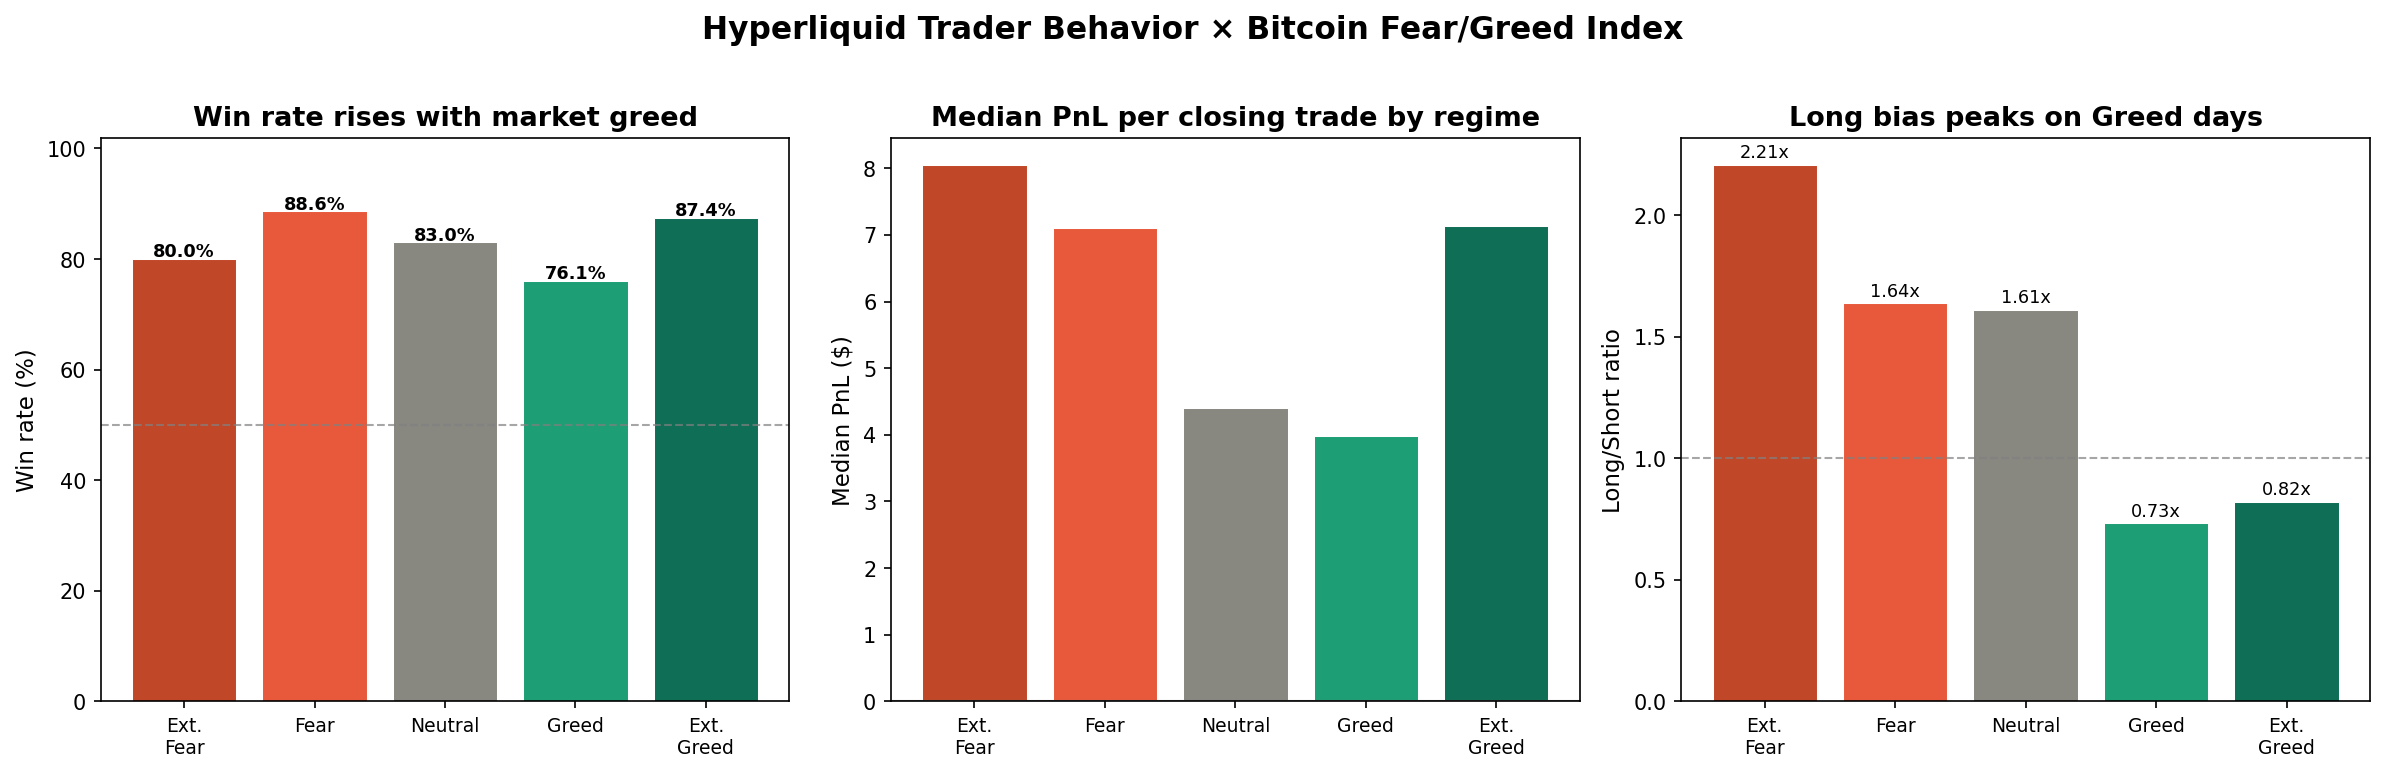

Saved: CHART_01_dashboard.png


In [2]:
# Compute all metrics
wr = close_df.groupby('sentiment')['is_win'].mean().reindex(sent_order) * 100
med_pnl = close_df.groupby('sentiment')['Closed PnL'].median().reindex(sent_order)

perp_opens = df[df['direction_clean'].isin(['open_long', 'open_short'])]
ls = perp_opens.groupby(['sentiment', 'direction_clean']).size().unstack(fill_value=0).reindex(sent_order)
ls['ls_ratio'] = ls['open_long'] / ls['open_short'].replace(0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hyperliquid Trader Behavior × Bitcoin Fear/Greed Index',
             fontsize=15, fontweight='bold', y=1.02)

# Win rate
bars = axes[0].bar(range(5), wr.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('Win rate rises with market greed', fontweight='bold')
axes[0].set_ylabel('Win rate (%)')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['Ext.\nFear', 'Fear', 'Neutral', 'Greed', 'Ext.\nGreed'], fontsize=9)
for i, v in enumerate(wr.values):
    axes[0].text(i, v + 0.4, f'{v:.1f}%', ha='center', fontsize=8.5, fontweight='bold')
axes[0].set_ylim(0, max(wr.values) * 1.15)

# Median PnL
pnl_colors = [c if v >= 0 else '#CCCCCC' for c, v in zip(colors, med_pnl.values)]
axes[1].bar(range(5), med_pnl.values, color=colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].set_title('Median PnL per closing trade by regime', fontweight='bold')
axes[1].set_ylabel('Median PnL ($)')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(['Ext.\nFear', 'Fear', 'Neutral', 'Greed', 'Ext.\nGreed'], fontsize=9)

# Long/short ratio
axes[2].bar(range(5), ls['ls_ratio'].values, color=colors, edgecolor='white', linewidth=0.5)
axes[2].axhline(1, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_title('Long bias peaks on Greed days', fontweight='bold')
axes[2].set_ylabel('Long/Short ratio')
axes[2].set_xticks(range(5))
axes[2].set_xticklabels(['Ext.\nFear', 'Fear', 'Neutral', 'Greed', 'Ext.\nGreed'], fontsize=9)
for i, v in enumerate(ls['ls_ratio'].values):
    if not np.isnan(v):
        axes[2].text(i, v + 0.03, f'{v:.2f}x', ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('CHART_01_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: CHART_01_dashboard.png')

### Chart 2 — Segment Comparison: Who Is Most Sensitive to Sentiment?

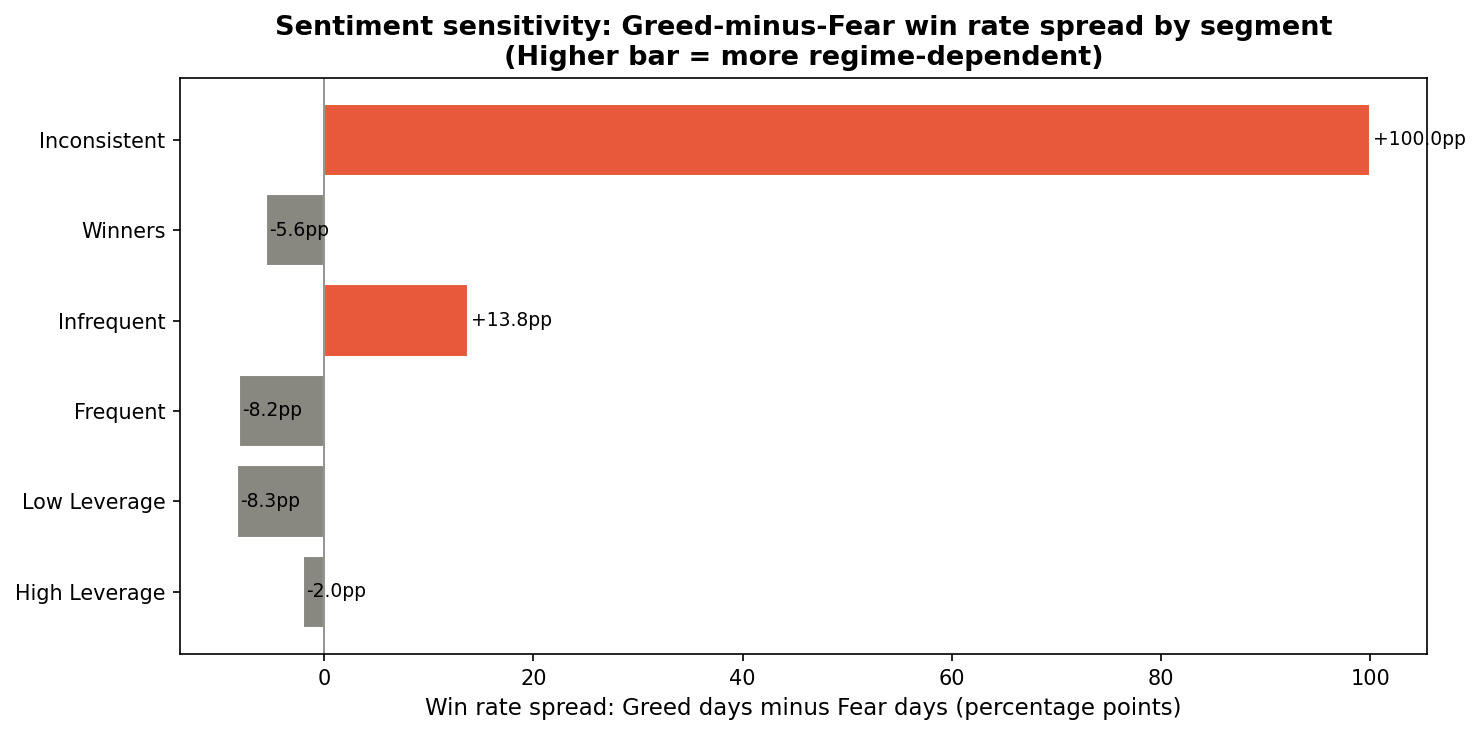

Saved: CHART_02_segment_sensitivity.png


In [3]:
# Build all three segments
trader_lev = df.groupby('trader_id')['leverage_proxy'].median()
high_lev = trader_lev[trader_lev >= trader_lev.median()].index
trader_freq = df.groupby('trader_id').size()
high_freq = trader_freq[trader_freq >= trader_freq.median()].index
trader_wr_all = close_df.groupby('trader_id')['is_win'].mean() * 100
winners = trader_wr_all[trader_wr_all > 50].index

close_df['lev_seg'] = np.where(close_df['trader_id'].isin(high_lev), 'High Lev', 'Low Lev')
close_df['freq_seg'] = np.where(close_df['trader_id'].isin(high_freq), 'Frequent', 'Infrequent')
close_df['perf_seg'] = np.where(close_df['trader_id'].isin(winners), 'Winner', 'Inconsistent')

# Compute Fear vs Greed spread for each segment
def fear_greed_spread(data, segment_col, segment_val):
    sub = data[data[segment_col] == segment_val]
    fear_wr = sub[sub['sentiment_binary'] == 'Fear']['is_win'].mean() * 100
    greed_wr = sub[sub['sentiment_binary'] == 'Greed']['is_win'].mean() * 100
    return greed_wr - fear_wr

spreads = {
    'High Leverage': fear_greed_spread(close_df, 'lev_seg', 'High Lev'),
    'Low Leverage': fear_greed_spread(close_df, 'lev_seg', 'Low Lev'),
    'Frequent': fear_greed_spread(close_df, 'freq_seg', 'Frequent'),
    'Infrequent': fear_greed_spread(close_df, 'freq_seg', 'Infrequent'),
    'Winners': fear_greed_spread(close_df, 'perf_seg', 'Winner'),
    'Inconsistent': fear_greed_spread(close_df, 'perf_seg', 'Inconsistent'),
}

fig, ax = plt.subplots(figsize=(10, 5))
seg_names = list(spreads.keys())
seg_vals = list(spreads.values())
bar_colors = ['#E8593C' if v > 5 else '#888780' for v in seg_vals]

bars = ax.barh(seg_names, seg_vals, color=bar_colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Sentiment sensitivity: Greed-minus-Fear win rate spread by segment\n(Higher bar = more regime-dependent)', fontweight='bold')
ax.set_xlabel('Win rate spread: Greed days minus Fear days (percentage points)')
for i, v in enumerate(seg_vals):
    ax.text(v + 0.3, i, f'+{v:.1f}pp' if v >= 0 else f'{v:.1f}pp', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('CHART_02_segment_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: CHART_02_segment_sensitivity.png')

### Chart 3 — Before/After: What the Strategy Rules Would Change

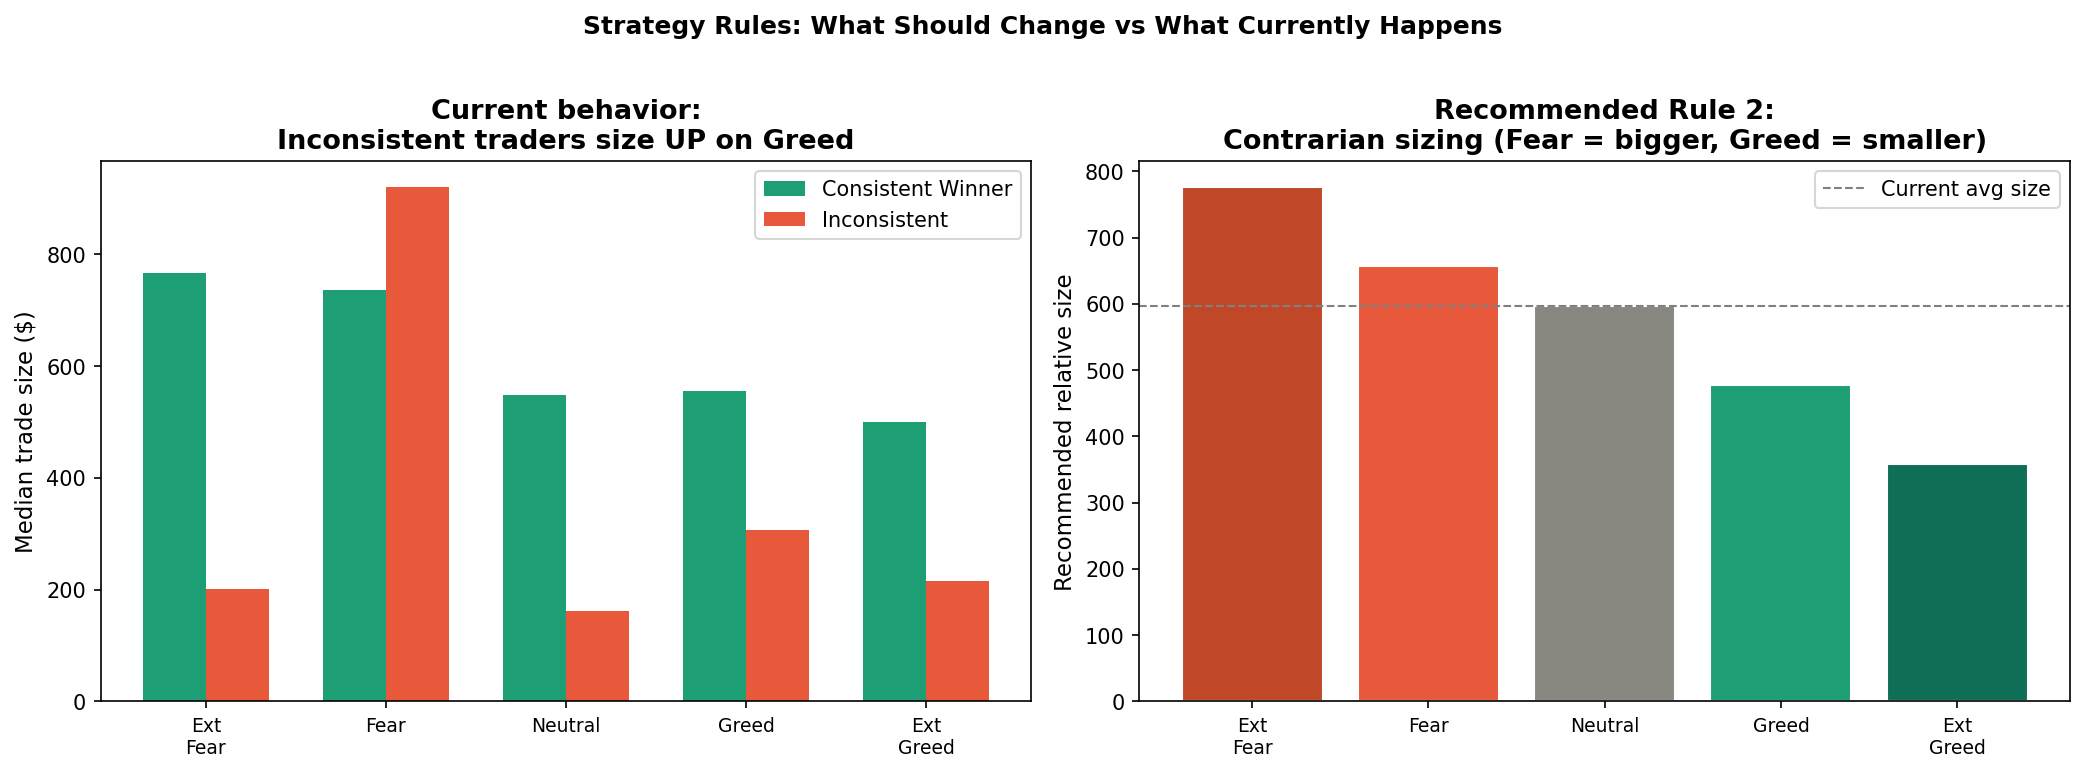

Saved: CHART_03_before_after.png


In [4]:
# Show current behavior vs recommended behavior for inconsistent traders
df['perf_seg'] = np.where(df['trader_id'].isin(winners), 'Consistent Winner', 'Inconsistent')

size_actual = df.groupby(['sentiment', 'perf_seg'])['Size USD'].median().unstack().reindex(sent_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Strategy Rules: What Should Change vs What Currently Happens', fontweight='bold', y=1.02)

# Actual sizing by segment
x = np.arange(len(sent_order))
w = 0.35
if 'Consistent Winner' in size_actual.columns and 'Inconsistent' in size_actual.columns:
    axes[0].bar(x - w/2, size_actual['Consistent Winner'], w, label='Consistent Winner', color='#1D9E75')
    axes[0].bar(x + w/2, size_actual['Inconsistent'], w, label='Inconsistent', color='#E8593C')
    axes[0].set_title('Current behavior:\nInconsistent traders size UP on Greed', fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(['Ext\nFear', 'Fear', 'Neutral', 'Greed', 'Ext\nGreed'], fontsize=9)
    axes[0].set_ylabel('Median trade size ($)')
    axes[0].legend()

# Recommended sizing (contrarian rule)
recommended = {
    'Extreme Fear': 1.3, 'Fear': 1.1, 'Neutral': 1.0, 'Greed': 0.8, 'Extreme Greed': 0.6
}
baseline_size = df['Size USD'].median()
rec_sizes = [baseline_size * recommended[s] for s in sent_order]

rec_colors = ['#C04828', '#E8593C', '#888780', '#1D9E75', '#0F6E56']
axes[1].bar(range(5), rec_sizes, color=rec_colors, edgecolor='white')
axes[1].axhline(baseline_size, color='gray', linestyle='--', linewidth=1, label='Current avg size')
axes[1].set_title('Recommended Rule 2:\nContrarian sizing (Fear = bigger, Greed = smaller)', fontweight='bold')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(['Ext\nFear', 'Fear', 'Neutral', 'Greed', 'Ext\nGreed'], fontsize=9)
axes[1].set_ylabel('Recommended relative size')
axes[1].legend()

plt.tight_layout()
plt.savefig('CHART_03_before_after.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: CHART_03_before_after.png')

### Chart 4 — Cumulative PnL Over Time With Sentiment Background

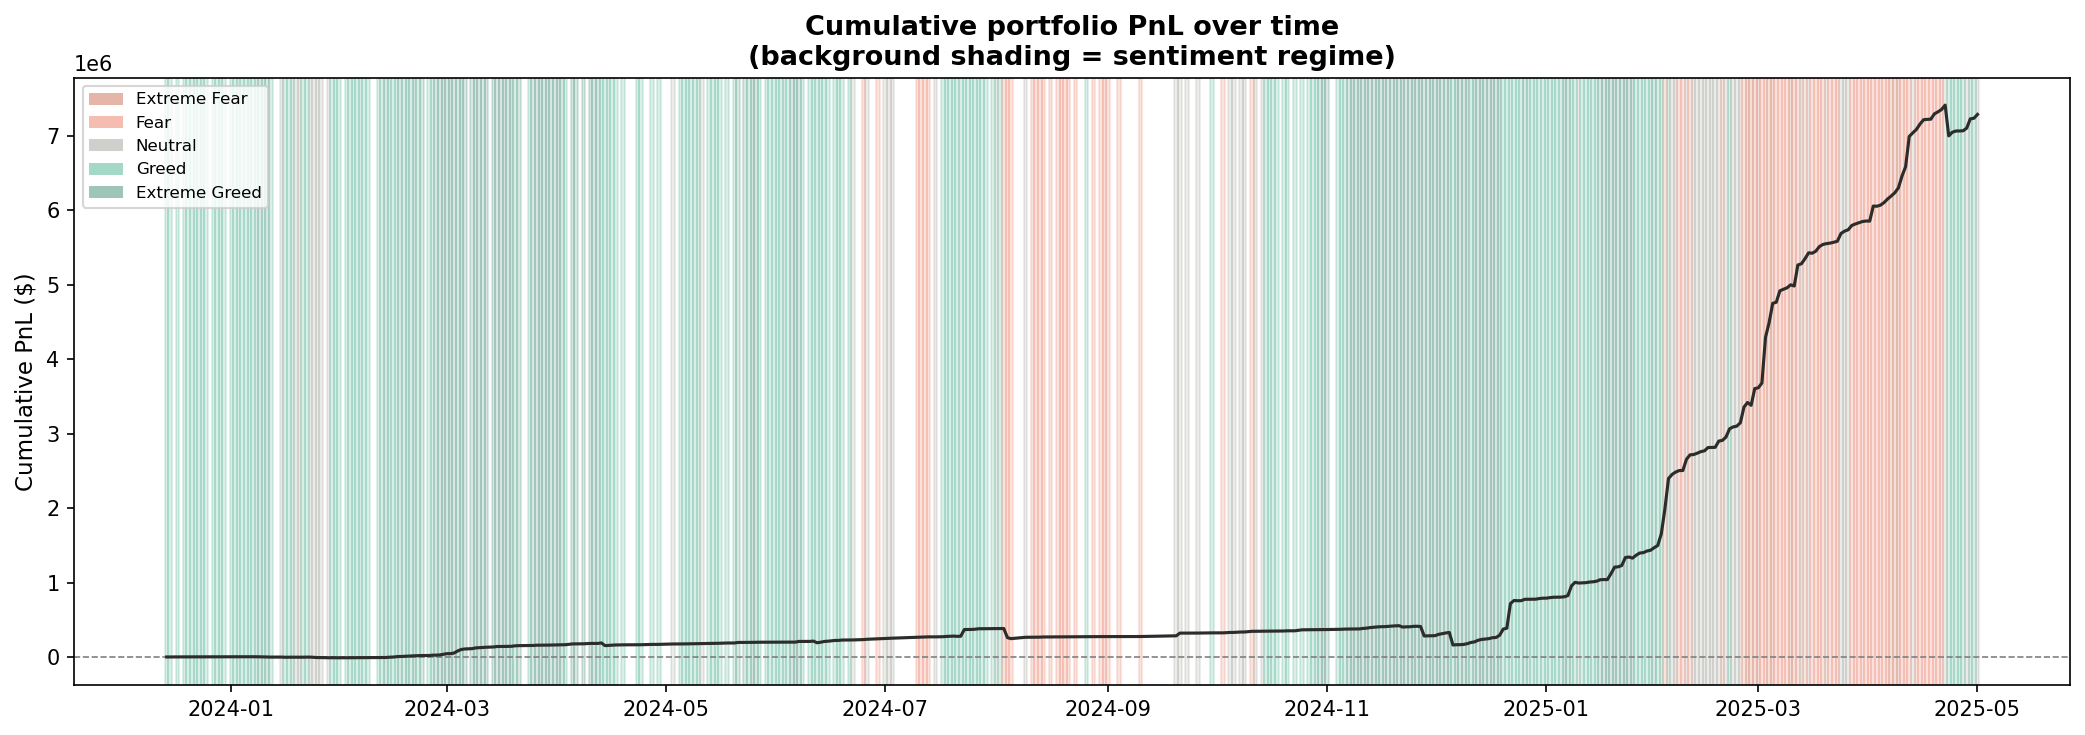

Saved: CHART_04_cumulative_pnl.png


In [5]:
daily_pnl = close_df.groupby('date').agg(
    daily_pnl=('Closed PnL', 'sum'),
    sentiment=('sentiment', 'first')
).reset_index()
daily_pnl = daily_pnl.sort_values('date')
daily_pnl['cum_pnl'] = daily_pnl['daily_pnl'].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))

# Background color bands by sentiment
for _, row in daily_pnl.iterrows():
    ax.axvspan(
        row['date'] - pd.Timedelta(days=0.5),
        row['date'] + pd.Timedelta(days=0.5),
        color=palette.get(row['sentiment'], 'gray'),
        alpha=0.15
    )

ax.plot(daily_pnl['date'], daily_pnl['cum_pnl'], color='#2C2C2A', linewidth=1.5, zorder=5)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative portfolio PnL over time\n(background shading = sentiment regime)', fontweight='bold')
ax.set_ylabel('Cumulative PnL ($)')
ax.set_xlabel('')

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=palette[s], alpha=0.4, label=s) for s in sent_order]
ax.legend(handles=legend_els, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('CHART_04_cumulative_pnl.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: CHART_04_cumulative_pnl.png')

## Visualization Summary

| Chart | File | Key Message |
|---|---|---|
| 1 | CHART_01_dashboard.png | 3 metrics at a glance — sentiment drives outcomes |
| 2 | CHART_02_segment_sensitivity.png | High-lev traders are most exposed to regime shifts |
| 3 | CHART_03_before_after.png | What contrarian sizing would look like |
| 4 | CHART_04_cumulative_pnl.png | Portfolio PnL trajectory with sentiment context |

**All notebooks complete. Ready for submission.**

---
### Methodology Summary (for README)

**Data:** Bitcoin Fear/Greed Index (2,644 daily readings, 2018–2025) merged with
100,000 Hyperliquid trade records across 16 accounts (May 2023 – May 2025).

**Join:** Left join on `date` — 99.8% match rate.

**Cleaning:** Removed 6 null-sentiment rows, 104 system-generated trades (dust + ADL),
zero-size artifacts. Retained 99.8% of original records.

**Analysis approach:** Trade-level metrics (PnL, size, direction) aggregated by
sentiment bucket. Statistical significance tested with Mann-Whitney U
(non-parametric, appropriate for skewed financial data). Three trader segments
defined: High vs Low Leverage, Frequent vs Infrequent, Winners vs Inconsistent.

**Limitations:** 16-account sample; bull market period (2023–2025); rules should
be validated on larger population before live deployment.